# Applied Machine Learning: Software Defect Prediction

**Author:** Belal Nwiran

**Dataset:** [Software Defect Prediction](https://www.kaggle.com/datasets/semustafacevik/software-defect-prediction)

This project builds a supervised machine learning model to predict whether a software module is defective. Each row in the dataset is one code module, described by static code metrics, and the target is a defect label (defective or not defective). The goal is to show how a model could help a team decide which modules to review or test first.

Because defective modules are usually much rarer than clean ones, accuracy alone can be misleading. The model will be judged mainly with precision, recall, and F1-score.

# Setup

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_validate
from sklearn.metrics import (
    make_scorer, precision_score, recall_score, f1_score, 
    accuracy_score, average_precision_score,
    classification_report, confusion_matrix,
    PrecisionRecallDisplay
)

# Ingestion

In [2]:
df = pd.read_csv('jm1.csv')
df.head()

,loc,v(g),ev(g),iv(g),n,v,l,d,i,e,...,lOCode,lOComment,lOBlank,locCodeAndComment,uniq_Op,uniq_Opnd,total_Op,total_Opnd,branchCount,defects
0,1.1,1.4,1.4,1.4,1.3,1.30,1.30,1.30,1.30,1.30,...,2,2,2,2,1.2,1.2,1.2,1.2,1.4,False
1,1.0,1.0,1.0,1.0,1.0,1.00,1.00,1.00,1.00,1.00,...,1,1,1,1,1,1,1,1,1,True
2,72.0,7.0,1.0,6.0,198.0,1134.13,0.05,20.31,55.85,23029.10,...,51,10,8,1,17,36,112,86,13,True
3,190.0,3.0,1.0,3.0,600.0,4348.76,0.06,17.06,254.87,74202.67,...,129,29,28,2,17,135,329,271,5,True
4,37.0,4.0,1.0,4.0,126.0,599.12,0.06,17.19,34.86,10297.30,...,28,1,6,0,11,16,76,50,7,True


In [3]:
df.shape

(10885, 22)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10885 entries, 0 to 10884
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   loc                10885 non-null  float64
 1   v(g)               10885 non-null  float64
 2   ev(g)              10885 non-null  float64
 3   iv(g)              10885 non-null  float64
 4   n                  10885 non-null  float64
 5   v                  10885 non-null  float64
 6   l                  10885 non-null  float64
 7   d                  10885 non-null  float64
 8   i                  10885 non-null  float64
 9   e                  10885 non-null  float64
 10  b                  10885 non-null  float64
 11  t                  10885 non-null  float64
 12  lOCode             10885 non-null  int64  
 13  lOComment          10885 non-null  int64  
 14  lOBlank            10885 non-null  int64  
 15  locCodeAndComment  10885 non-null  int64  
 16  uniq_Op            10885 non-null

In [5]:
df.duplicated().sum()

np.int64(1973)

## Some observations

 * **Size:** 10,885 rows with 22 columns.
 * **Wrong types:** five columns (uniq_Op, uniq_Opnd, total_Op, total_Opnd, branchCount) loaded as strings although they should be numeric.
 * **Suspicious rows:** row 0 has decimal values in count columns, and row 1 has all values equal to 1.
 * **Duplicates:** 1,973 duplicated rows (about 18%).

# Data Preparation and Preprocessing

In [6]:
def drop_duplicated_rows(df: pd.DataFrame) -> pd.DataFrame:
    duplicated_rows_count = df.duplicated().sum()
    df = df.drop_duplicates(keep="first").reset_index(drop=True)

    print(f"{duplicated_rows_count} of duplicated rows were dropped")

    return df

In [7]:
def convert_count_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    str_cols = ["uniq_Op", "uniq_Opnd", "total_Op", "total_Opnd", "branchCount"]

    df[str_cols] = df[str_cols].apply(pd.to_numeric, errors="coerce")

    return df

In [8]:
def drop_missing_rows(df: pd.DataFrame) -> pd.DataFrame:
    """Remove rows with missing values and report how many."""
    result = df.dropna().reset_index(drop=True)
    print(f"{len(df) - len(result)} rows were removed")
    return result

In [9]:
def add_halstead_missing_flag(df: pd.DataFrame) -> pd.DataFrame:
    """Add a 0/1 column marking modules whose Halstead metrics were not measured.

    In this dataset, some modules have real structural metrics (loc, v(g),
    branchCount) but every token-based Halstead metric equals 0. Volume (v)
    is 0 in all of these rows, so v == 0 is used as the marker. The original
    zeros are left unchanged.
    """
    out = df.copy()
    out["halstead_missing"] = (out["v"] == 0).astype(int)
    print(f"{out['halstead_missing'].sum()} rows "
          f"({out['halstead_missing'].mean():.2%}) flagged")
    return out

## Cleaning

In [10]:
# Cleaning
cleaned_df = drop_duplicated_rows(df)
cleaned_df = convert_count_columns(cleaned_df)
cleaned_df = drop_missing_rows(cleaned_df)
cleaned_df = add_halstead_missing_flag(cleaned_df)

1973 of duplicated rows were dropped
5 rows were removed
982 rows (11.03%) flagged


In [11]:
cleaned_df.shape

(8907, 23)

In [12]:
cleaned_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8907 entries, 0 to 8906
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   loc                8907 non-null   float64
 1   v(g)               8907 non-null   float64
 2   ev(g)              8907 non-null   float64
 3   iv(g)              8907 non-null   float64
 4   n                  8907 non-null   float64
 5   v                  8907 non-null   float64
 6   l                  8907 non-null   float64
 7   d                  8907 non-null   float64
 8   i                  8907 non-null   float64
 9   e                  8907 non-null   float64
 10  b                  8907 non-null   float64
 11  t                  8907 non-null   float64
 12  lOCode             8907 non-null   int64  
 13  lOComment          8907 non-null   int64  
 14  lOBlank            8907 non-null   int64  
 15  locCodeAndComment  8907 non-null   int64  
 16  uniq_Op            8907 non-null   

### Conclusion of Cleaning

* There are 982 rows with all token-based metrics equal to 0 but real structural metrics.
* I kept them because dropping would lose 11% of the data and valid structural information.
* So I added a halstead_missing flag and left the zeros as they are. The choice on imputing them will wait for the model choice.

### Dataset splitting

In [13]:
X = cleaned_df.drop(columns="defects")
y = cleaned_df["defects"].astype(int)   # True/False -> 1/0

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,        # keeps the defect rate the same in both sets
    random_state=42,
)

print("Train:", X_train.shape, " Test:", X_test.shape)
print("Defect rate - train:", y_train.mean(), " test:", y_test.mean())

Train: (7125, 22)  Test: (1782, 22)
Defect rate - train: 0.22498245614035087  test: 0.2250280583613917


## Conclusion

1. **Converting the five text columns**
   * `uniq_Op`, `uniq_Opnd`, `total_Op`, `total_Opnd` and `branchCount` contained ?.
   * They were converted to numbers, with ? becoming NaN, because the data description lists them as numeric.

2. **Removing duplicates:** 1,973 exact duplicate rows were removed (10,885 → 8,912).

   * Why: duplicates add no information, and copies on both sides of the split would inflate test scores.
   * The defect rate moved from 19.35% to 22.49% afterwards.

3. **Removing rows with missing values**

   * 5 rows with ? were dropped (0.05% of the data), so no imputation was needed.

4. **Zero-volume rows (kept and flagged)**

   * 982 rows (11.03%) have all token-based Halstead metrics at 0, but real loc, v(g) and branchCount. This looks like a measurement gap, which is my inference and not something the dataset documents.
   * Their defect rate is 30.96%, against 22.49% overall.
   * Why kept: dropping them would lose 11% of the data and valid structural metrics.
   * What I did: added a halstead_missing flag and left the zeros unchanged. Whether to treat them as missing is a Task 4 decision.

5. **Encoding and scaling**

   * No encoding was needed, since all features are numeric.
   * Scaling is deferred to the model pipeline, so it is fitted on training data only.

6. **Train/test split**

   * 80/20, stratified on defects.
   * I got: Train: 7125 rows  Test: 1782 rows, with defect rate - train: 22.50% and test: 22.50%
   * Why stratified: it keeps the class balance the same in both sets.

# Model Selection and Training

**Models:** a `DummyClassifier` baseline, Logistic Regression, and Random Forest.

**Zero-volume rows (same treatment for both models):** in the 982 flagged rows, the token-based Halstead metrics are set to missing (NaN) and filled with the training median. The `halstead_missing` flag stays as a feature, so the model can still use the signal that these rows have a higher defect rate.

**Imbalance:** both models use `class_weight="balanced"`.

**Leakage:** all steps live inside a `Pipeline`, so imputation and scaling are fitted on training data only. The test set is not used in this section.

In [14]:
# Checking the assumption first
TOKEN_COLS = ["v", "l", "d", "i", "e", "b", "t", "uniq_Opnd", "total_Opnd"]

flagged = X_train[X_train["halstead_missing"] == 1]
print("Flagged rows in train:", len(flagged))
print("Non-zero values in token columns of flagged rows:")
print((flagged[TOKEN_COLS] != 0).sum())
print("Smallest value in any training feature:", X_train.min().min())  # must be >= 0 for log1p

Flagged rows in train: 802
Non-zero values in token columns of flagged rows:
v             0
l             0
d             0
i             0
e             0
b             0
t             0
uniq_Opnd     0
total_Opnd    0
dtype: int64
Smallest value in any training feature: 0.0


In [15]:
def zeros_to_nan(df: pd.DataFrame) -> pd.DataFrame:
    """Set token-based Halstead metrics to NaN in rows flagged as not measured."""
    df = df.copy()
    df.loc[df["halstead_missing"] == 1, TOKEN_COLS] = np.nan
    return df

In [16]:
def build_pipeline(model, log_scale: bool = False) -> Pipeline:
    """Zeros -> NaN, median imputation, optional log1p + scaling, then the model."""
    steps = [
        ("zeros_to_nan", FunctionTransformer(zeros_to_nan, feature_names_out="one-to-one")),
        ("impute", SimpleImputer(strategy="median")),
    ]
    if log_scale:  # Logistic Regression is sensitive to skew and feature scale
        steps += [
            ("log1p", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
            ("scale", StandardScaler()),
        ]
    steps.append(("model", model))
    pipe = Pipeline(steps)
    pipe.set_output(transform="pandas")  # keeps column names for later interpretation
    return pipe

In [17]:
# cross-validation setup and baseline
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score),
    "f1": make_scorer(f1_score),
}

baseline = cross_validate(DummyClassifier(strategy="most_frequent"),
                          X_train, y_train, cv=cv, scoring=scoring)
print({k.replace("test_", ""): round(v.mean(), 3)
       for k, v in baseline.items() if k.startswith("test_")})

{'precision': np.float64(0.0), 'recall': np.float64(0.0), 'f1': np.float64(0.0)}


In [18]:
lr_search = GridSearchCV(
    build_pipeline(LogisticRegression(class_weight="balanced", max_iter=1000,
                                      random_state=42), log_scale=True),
    param_grid={"model__C": [0.01, 0.1, 1, 10]},
    cv=cv, scoring="f1",
).fit(X_train, y_train)

rf_search = GridSearchCV(
    build_pipeline(RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                          random_state=42, n_jobs=-1)),
    param_grid={"model__max_depth": [5, 10, None],
                "model__min_samples_leaf": [1, 5, 10]},
    cv=cv, scoring="f1",
).fit(X_train, y_train)

for name, search in [("Logistic Regression", lr_search), ("Random Forest", rf_search)]:
    print(f"{name}: best params = {search.best_params_}, CV F1 = {search.best_score_:.3f}")

Logistic Regression: best params = {'model__C': 0.01}, CV F1 = 0.447
Random Forest: best params = {'model__max_depth': 10, 'model__min_samples_leaf': 5}, CV F1 = 0.457


In [19]:
def cv_summary(search, name):
    """Mean CV precision/recall/F1 (training data only) for the best setting."""
    res = cross_validate(search.best_estimator_, X_train, y_train, cv=cv, scoring=scoring)
    return {"model": name, **{m: round(res[f"test_{m}"].mean(), 3) for m in scoring}}

cv_table = pd.DataFrame([
    {"model": "Dummy (most frequent)",
     **{m: round(baseline[f"test_{m}"].mean(), 3) for m in scoring}},
    cv_summary(lr_search, "Logistic Regression"),
    cv_summary(rf_search, "Random Forest"),
])
cv_table

,model,precision,recall,f1
0,Dummy (most frequent),0.000,0.000,0.000
1,Logistic Regression,0.362,0.583,0.447
2,Random Forest,0.398,0.536,0.457


In [20]:
for name, search in [("Logistic Regression", lr_search), ("Random Forest", rf_search)]:
    res = cross_validate(search.best_estimator_, X_train, y_train, cv=cv, scoring=scoring)
    print(f"{name}: F1 = {res['test_f1'].mean():.3f} ± {res['test_f1'].std():.3f}")

Logistic Regression: F1 = 0.447 ± 0.014
Random Forest: F1 = 0.457 ± 0.019


## Conclusion

* **Setup:** I trained a baseline (`DummyClassifier`), Logistic Regression, and Random Forest. Both models used `class_weight="balanced"` and the same preprocessing: the token-based Halstead zeros in flagged rows became missing values and were filled with the training median, and `halstead_missing` was kept as a feature. Everything ran inside a `Pipeline`, with 5-fold stratified cross-validation on the training set only. The test set was not used.
* **Baseline:** the dummy model always predicts "not defective", so its precision, recall, and F1 are all 0.
* **Models:** both models beat the baseline with similar results. Logistic Regression scored F1 = 0.447 ± 0.014 and Random Forest scored F1 = 0.457 ± 0.019. The gap of 0.010 is smaller than the variation between folds, so I do not treat one model as better on F1.
* **Trade-off:** Logistic Regression had higher recall (0.583 vs 0.536), so it finds more defective modules. Random Forest had higher precision (0.398 vs 0.362), so its flags are slightly more reliable.
* **Limitation:** performance is modest. Precision is about 0.36 to 0.40, so about 6 in 10 flagged modules are clean, and recall is about 0.54 to 0.58, so many defective modules are still missed. Precision is still well above the 22.5% defect rate.
* **Best settings:** C = 0.01 for Logistic Regression, max_depth = 10 and min_samples_leaf = 5 for Random Forest.

# Evaluation

The two models and the baseline are evaluated **once** on the held-out test set. No model or preprocessing changes were made after seeing these results. The main metrics are precision, recall, and F1 for the defective class. Accuracy is shown only to show why it is misleading here.

In [23]:
# The baseline was only cross-validated in Task 4, so fit it on the full training set here
baseline_model = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)

models = {
    "Dummy (most frequent)": baseline_model,
    "Logistic Regression": lr_search.best_estimator_,
    "Random Forest": rf_search.best_estimator_,
}


def evaluate(model, name: str) -> dict:
    """Test-set metrics for the defective class (default 0.5 threshold)."""
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    return {
        "model": name,
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred),
        "f1": f1_score(y_test, pred),
        "avg_precision": average_precision_score(y_test, proba),
    }


test_table = pd.DataFrame([evaluate(m, n) for n, m in models.items()]).set_index("model").round(3)
test_table

,accuracy,precision,recall,f1,avg_precision
model,,,,,
Dummy (most frequent),0.775,0.000,0.000,0.000,0.225
Logistic Regression,0.670,0.361,0.603,0.451,0.407
Random Forest,0.705,0.393,0.574,0.467,0.417


In [24]:
for name, model in list(models.items())[1:]:
    print(name)
    print(classification_report(y_test, model.predict(X_test),
                                target_names=["Clean", "Defective"], zero_division=0))

Logistic Regression
              precision    recall  f1-score   support

       Clean       0.86      0.69      0.76      1381
   Defective       0.36      0.60      0.45       401

    accuracy                           0.67      1782
   macro avg       0.61      0.65      0.61      1782
weighted avg       0.75      0.67      0.69      1782

Random Forest
              precision    recall  f1-score   support

       Clean       0.86      0.74      0.80      1381
   Defective       0.39      0.57      0.47       401

    accuracy                           0.70      1782
   macro avg       0.63      0.66      0.63      1782
weighted avg       0.75      0.70      0.72      1782



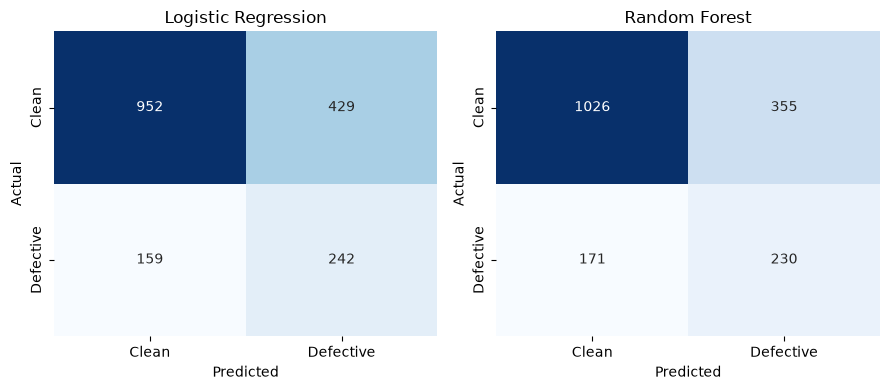

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, (name, model) in zip(axes, list(models.items())[1:]):
    cm = confusion_matrix(y_test, model.predict(X_test))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["Clean", "Defective"], yticklabels=["Clean", "Defective"])
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

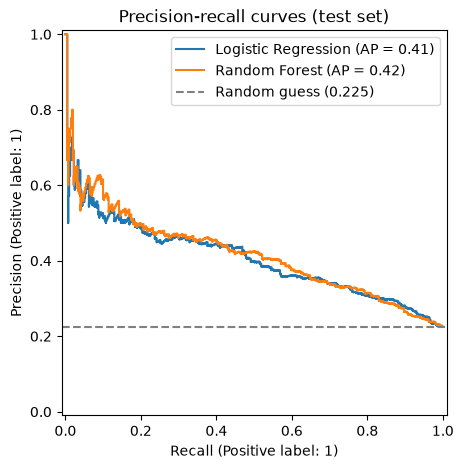

In [26]:
fig, ax = plt.subplots(figsize=(6, 5))
for name, model in list(models.items())[1:]:
    PrecisionRecallDisplay.from_estimator(model, X_test, y_test, name=name, ax=ax)
ax.axhline(y_test.mean(), color="gray", linestyle="--",
           label=f"Random guess ({y_test.mean():.3f})")
ax.set_title("Precision-recall curves (test set)")
ax.legend()
plt.show()

In [27]:
names = ["Logistic Regression", "Random Forest"]
cv_f1 = cv_table.set_index("model")["f1"]

comparison = pd.DataFrame({
    "train_f1": {n: f1_score(y_train, models[n].predict(X_train)) for n in names},
    "cv_f1": cv_f1[names],
    "test_f1": test_table.loc[names, "f1"],
}).round(3)
comparison

,train_f1,cv_f1,test_f1
Logistic Regression,0.447,0.447,0.451
Random Forest,0.628,0.457,0.467


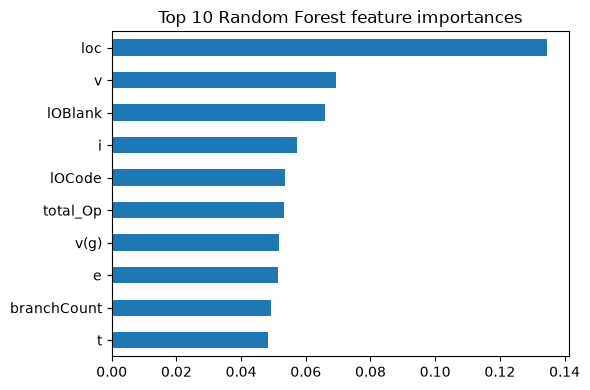

In [28]:
rf_model = models["Random Forest"]
importances = pd.Series(
    rf_model.named_steps["model"].feature_importances_,
    index=rf_model[:-1].get_feature_names_out(),
).sort_values().tail(10)

importances.plot(kind="barh", figsize=(6, 4), title="Top 10 Random Forest feature importances")
plt.tight_layout()
plt.show()

# Summary

I built a supervised model to predict whether a software module is defective, using static code metrics from the software defect prediction dataset (8,907 modules after cleaning, 22.5% defective). I compared a baseline that always predicts "not defective" with Logistic Regression and Random Forest, both using balanced class weights and a pipeline that fills the missing token-based Halstead values with training medians. On the held-out test set, Logistic Regression reached F1 = 0.451 (precision 0.361, recall 0.603) and Random Forest reached F1 = 0.467 (precision 0.393, recall 0.574), while the baseline scored 0 on all three despite 77.5% accuracy. Test F1 was close to cross-validated F1 (about 0.45 to 0.46) for both models, so the results look stable, and the small gap between the two models should not be over-read. The main limitation is modest precision: about 6 in 10 flagged modules are actually clean, and about 4 in 10 defective modules are missed. Data challenges included 1,973 duplicate rows and 982 rows with unmeasured Halstead metrics, which I handled with removal and a missing-value flag.